# Cell Health Feature Heatmap Visualization

**Local visualization of normalized cell health features**

This notebook generates publication-quality heatmaps from the normalized cell health data without requiring external tools like Morpheus.


In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import linkage
import warnings
warnings.filterwarnings('ignore')

# Set plotting parameters
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 300
sns.set_style("whitegrid")


## Load and Explore Data

**Note**: This notebook automatically handles NaN values in the data by removing features with >50% missing values and filling remaining NaN values with median values.


In [ ]:
# Load normalized cell health data
data_file = os.path.join("data", "labels", "normalized_cell_health_labels.tsv")
df = pd.read_csv(data_file, sep='\t')

# Load feature mapping for better labels
mapping_file = os.path.join("data", "labels", "feature_mapping_annotated.csv")
feature_map = pd.read_csv(mapping_file)

print(f"Loaded data shape: {df.shape}")
print(f"Cell lines: {df['cell_id'].unique()}")
print(f"Number of guides: {len(df['guide'].unique())}")

# Show sample data
df.head(2)


Loaded data shape: (2302, 75)
Cell lines: ['ES2' 'A549' 'HCC44']
Number of guides: 126


,cell_id,guide,plate_name,well_col,well_row,cc_all_high_h2ax,cc_all_large_notround_polynuclear_mean,cc_all_large_round_polyploid_mean,cc_all_n_objects,cc_all_n_spots_h2ax_mean,...,vb_num_live_cells,vb_percent_all_apoptosis,vb_percent_caspase_dead_only,vb_percent_dead,vb_percent_dead_only,vb_percent_early_apoptosis,vb_percent_late_apoptosis,vb_percent_live,vb_ros_back_mean,vb_ros_mean
0,ES2,AKT1-1,Plate 1,3,A,0.655229,-0.565658,-0.839186,-0.513748,0.313600,...,0.281397,-0.279051,-0.920300,-0.139875,-0.016549,-0.429141,-0.177258,0.140570,NaN,NaN
1,ES2,AKT1-1,Plate 1,22,O,-0.251336,-0.816445,-0.525940,-0.819810,-0.450799,...,0.543716,-0.221588,-1.070176,-0.046783,0.268559,-0.311041,-0.149198,0.040163,-0.29248,0.008339


In [ ]:
# Prepare data for heatmap
metadata_cols = ['cell_id', 'guide', 'plate_name', 'well_col', 'well_row']
feature_cols = [col for col in df.columns if col not in metadata_cols]

print(f"Original data has {df[feature_cols].isnull().sum().sum()} NaN values")

# Aggregate by cell line and guide (average across replicates)
agg_df = df.groupby(['cell_id', 'guide'])[feature_cols].mean().reset_index()
agg_df['sample_label'] = agg_df['cell_id'] + '_' + agg_df['guide']

print(f"Aggregated to {len(agg_df)} unique samples")
print(f"Available {len(feature_cols)} features")
print(f"NaN values after aggregation: {agg_df[feature_cols].isnull().sum().sum()}")

# Handle NaN values - Remove features with too many NaN values
nan_threshold = 0.5  # Remove features with >50% NaN values
feature_nan_counts = agg_df[feature_cols].isnull().mean()
valid_features = feature_nan_counts[feature_nan_counts < nan_threshold].index.tolist()

print(f"Removed {len(feature_cols) - len(valid_features)} features with >50% NaN values")
print(f"Remaining features: {len(valid_features)}")

# For remaining NaN values, fill with feature median (common approach)
agg_df[valid_features] = agg_df[valid_features].fillna(agg_df[valid_features].median())

print(f"After cleanup - NaN values: {agg_df[valid_features].isnull().sum().sum()}")

# Select most variable features (for readability)
max_features = 40
if len(valid_features) > max_features:
    feature_data = agg_df[valid_features]
    feature_variance = feature_data.var().sort_values(ascending=False)
    top_features = feature_variance.head(max_features).index.tolist()
    print(f"Selected top {max_features} most variable features")
else:
    top_features = valid_features
    print(f"Using all {len(valid_features)} valid features")

# Create readable feature names
feature_name_map = dict(zip(feature_map['id'], feature_map['readable_name']))
readable_names = [feature_name_map.get(f, f)[:40] for f in top_features]

# Final heatmap data - now guaranteed to have no NaN values
heatmap_data = agg_df.set_index('sample_label')[top_features]
print(f"Final heatmap shape: {heatmap_data.shape}")
print(f"Final data check - NaN: {heatmap_data.isnull().sum().sum()}, Inf: {np.isinf(heatmap_data).sum().sum()}")


Original data has 2085 NaN values
Aggregated to 364 unique samples
Available 70 features
NaN values after aggregation: 60
Removed 0 features with >50% NaN values
Remaining features: 70
After cleanup - NaN values: 0
Selected top 40 most variable features
Final heatmap shape: (364, 40)
Final data check - NaN: 0, Inf: 0


## Generate Publication-Quality Heatmaps


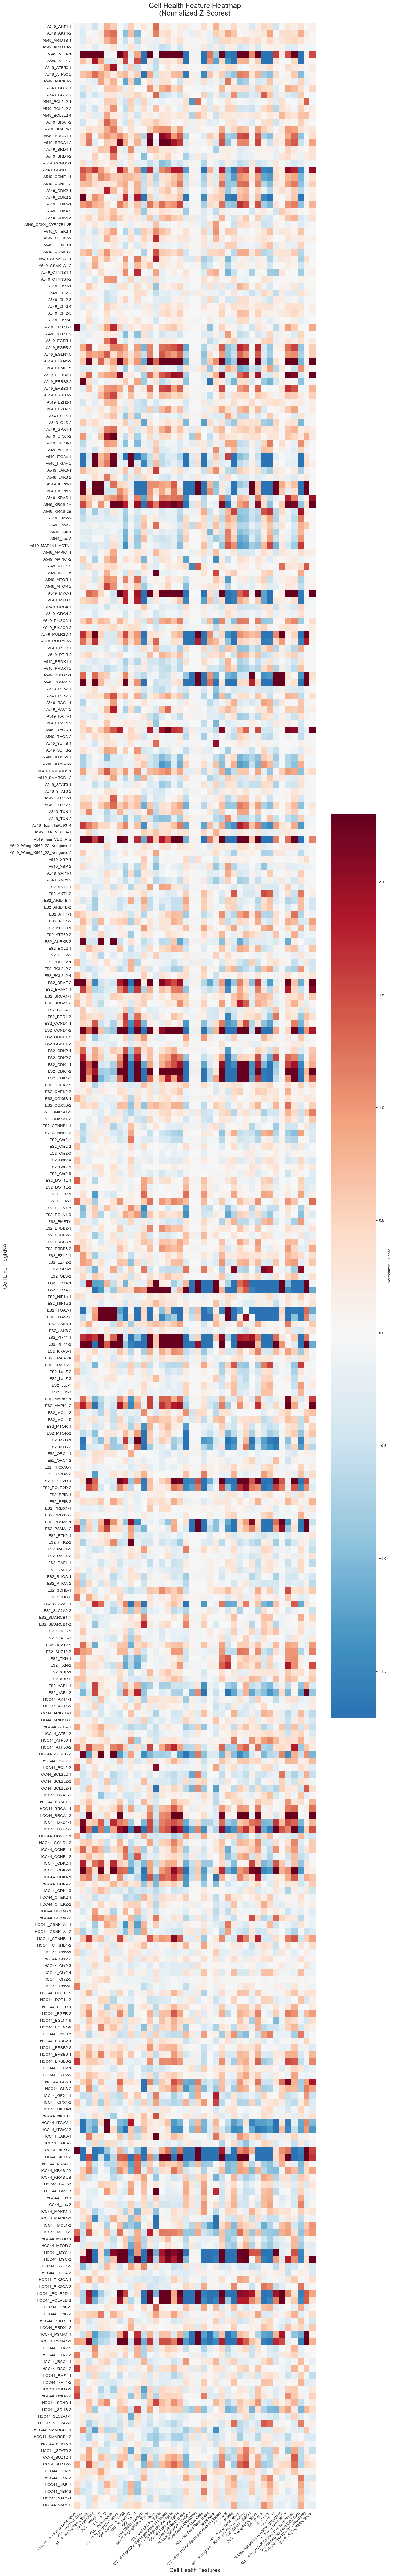

✅ Heatmap saved as:
   📄 figures/cell_health_feature_heatmap.pdf
   🖼️ figures/cell_health_feature_heatmap.png


In [ ]:
# Create main heatmap
os.makedirs('figures', exist_ok=True)

fig_width = max(14, len(readable_names) * 0.3)
fig_height = max(10, heatmap_data.shape[0] * 0.25)

plt.figure(figsize=(fig_width, fig_height))

# Generate heatmap
sns.heatmap(heatmap_data, 
            cmap='RdBu_r',  # Red=high, Blue=low
            center=0,       # Center at zero (since data is normalized)
            robust=True,    # Use robust quantiles for color scale
            xticklabels=readable_names,
            yticklabels=True,
            cbar_kws={'label': 'Normalized Z-Score', 'shrink': 0.8})

plt.title('Cell Health Feature Heatmap\n(Normalized Z-Scores)', fontsize=18, pad=20)
plt.xlabel('Cell Health Features', fontsize=14)
plt.ylabel('Cell Line + sgRNA', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

# Save high-resolution versions
plt.savefig('figures/cell_health_feature_heatmap.pdf', dpi=300, bbox_inches='tight')
plt.savefig('figures/cell_health_feature_heatmap.png', dpi=300, bbox_inches='tight')

plt.show()

print("Heatmap saved as:")
print("    figures/cell_health_feature_heatmap.pdf") 
print("    figures/cell_health_feature_heatmap.png")


Creating hierarchically clustered heatmap...


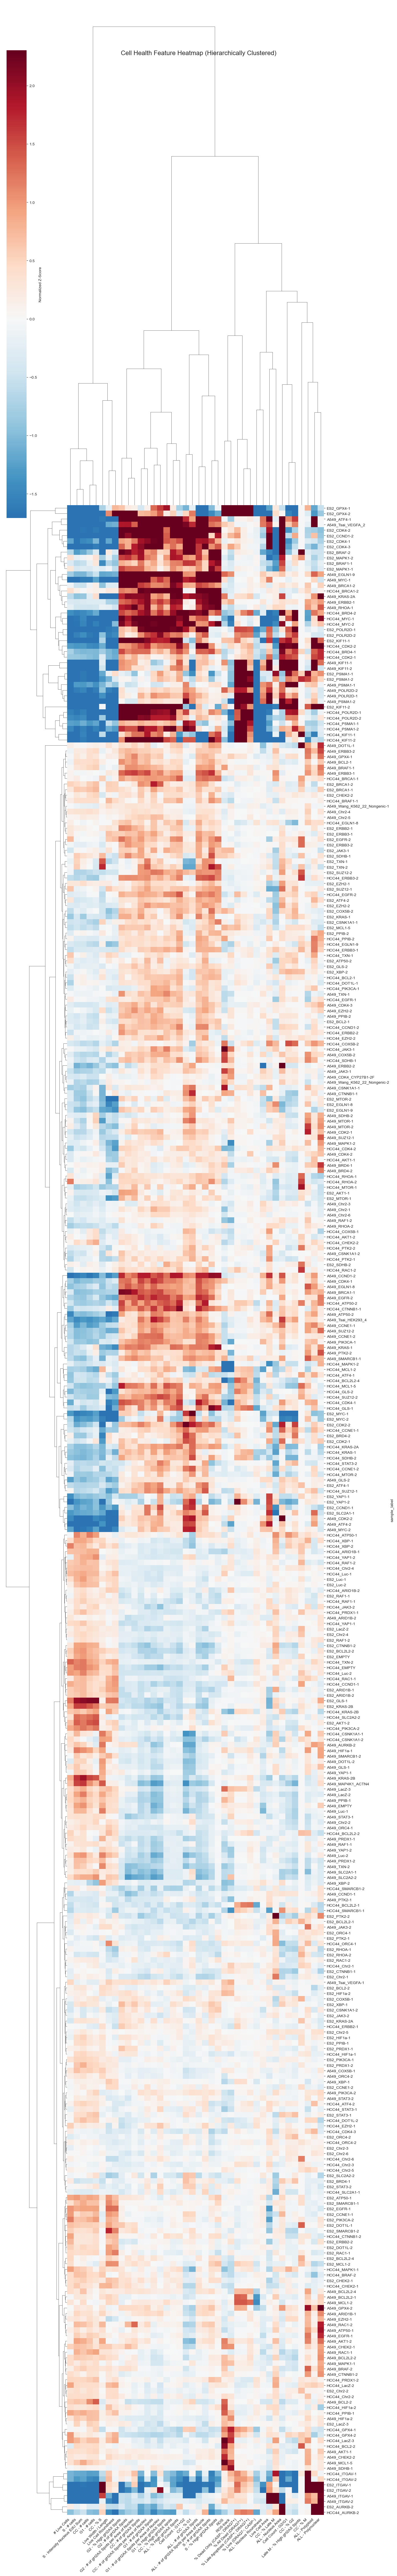

✅ Clustered heatmap saved as:
   🌳 figures/cell_health_feature_heatmap_clustered.pdf
   🖼️ figures/cell_health_feature_heatmap_clustered.png

🎉 Generated heatmaps for 364 samples and 40 features!


In [ ]:
# Create clustered heatmap with dendrograms
print("Creating hierarchically clustered heatmap...")

g = sns.clustermap(heatmap_data,
                   method='ward',           # Clustering method
                   cmap='RdBu_r',
                   center=0,
                   robust=True,
                   xticklabels=readable_names,
                   yticklabels=True,
                   figsize=(max(14, len(readable_names) * 0.3), 
                           max(10, heatmap_data.shape[0] * 0.25)),
                   cbar_kws={'label': 'Normalized Z-Score'})

g.fig.suptitle('Cell Health Feature Heatmap (Hierarchically Clustered)', 
               fontsize=16, y=0.98)

# Rotate x-axis labels for better readability
g.ax_heatmap.set_xticklabels(g.ax_heatmap.get_xticklabels(), rotation=45, ha='right')

# Save clustered version
g.savefig('figures/cell_health_feature_heatmap_clustered.pdf', dpi=300, bbox_inches='tight')
g.savefig('figures/cell_health_feature_heatmap_clustered.png', dpi=300, bbox_inches='tight')

plt.show()

print(" Clustered heatmap saved as:")
print("    figures/cell_health_feature_heatmap_clustered.pdf")
print("    figures/cell_health_feature_heatmap_clustered.png")

print(f"\n Generated heatmaps for {heatmap_data.shape[0]} samples and {heatmap_data.shape[1]} features!")
